In [1]:
# Instalação de dependências e download do modelo pesado logo no início e em modo silencioso (-q)
!pip install -q transformers torch scikit-learn matplotlib seaborn tqdm nltk spacy
!python -m spacy download pt_core_news_lg -q

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Componentes de Deep Learning e NLP
import torch
import spacy
from spacy.training.example import Example
from spacy.util import minibatch, compounding, filter_spans
from transformers import AutoTokenizer, AutoModel
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
warnings.filterwarnings("ignore")

# Configuração de dispositivo de hardware 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Pipeline operando no dispositivo: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 3.1 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Pipeline operando no dispositivo: cuda


In [2]:
# Célula 2: Carregamento do Dataset Real, Criação de 'Texto_Completo' e Configuração de Stopwords
import pandas as pd
import nltk
from nltk.corpus import stopwords
import spacy

# 1. Caminho obrigatório do arquivo no ambiente do Kaggle
caminho_arquivo = '/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv'

# 2. Carregamento estrito da base real 
df = pd.read_csv(caminho_arquivo, sep='\t', encoding='latin1')

# 3. Limpeza de valores nulos nas colunas que o professor solicitou a fusão
df = df.dropna(subset=['Título_Público', 'Descricao_pública'])

# 4. Engenharia de Atributos: Criação da coluna unificada exigida pelo fluxo do trabalho
df['Texto_Completo'] = df['Título_Público'].str.strip() + " [CONTEXTO] " + df['Descricao_pública'].str.strip()

# 5. Configuração do Universo Avançado de Stopwords 
nltk.download('stopwords', quiet=True)
stopwords_nltk = set(stopwords.words('portuguese'))
nlp_stopwords = spacy.load("pt_core_news_lg")
stopwords_spacy = nlp_stopwords.Defaults.stop_words

jargoes_cientificos = {
    'projeto', 'desenvolvimento', 'pesquisa', 'objetivo', 'visando', 'desenvolver', 
    'estudo', 'focado', 'utilizando', 'através', 'meio', 'título', 'público', 'pública',
    'contexto', 'empresa', 'processo', 'tecnologia', 'aplicação', 'sistema', 'sistemas'
}
UNIVERSO_STOPWORDS = stopwords_nltk.union(stopwords_spacy).union(jargoes_cientificos)

print("Célula 2 concluída com sucesso!")
print(f" -> Total de projetos REAIS carregados: {len(df)}")
print(" -> Coluna 'Texto_Completo' gerada com sucesso.")
print(f" -> Universo de Stopwords configurado com {len(UNIVERSO_STOPWORDS)} termos.")

Célula 2 concluída com sucesso!
 -> Total de projetos REAIS carregados: 2721
 -> Coluna 'Texto_Completo' gerada com sucesso.
 -> Universo de Stopwords configurado com 518 termos.


In [3]:
# Célula 3: Extração de Entidades via Supervisão Fraca (Weak Supervision)
print("A inicializar o modelo de linguagem base (pt_core_news_lg)...")
nlp_base = spacy.load("pt_core_news_lg")

# Acoplamento do componente de regras determinísticas ANTES do NER estatístico
if "entity_ruler" not in nlp_base.pipe_names:
    ruler = nlp_base.add_pipe("entity_ruler", before="ner")
else:
    ruler = nlp_base.get_pipe("entity_ruler")

# Dicionário de Domínio focado em Inovação, Tecnologia e Ciência
padroes_customizados = [
    {"label": "TECNOLOGIA_DIGITAL", "pattern": [{"LOWER": "inteligência"}, {"LOWER": "artificial"}]},
    {"label": "TECNOLOGIA_DIGITAL", "pattern": [{"LOWER": "machine"}, {"LOWER": "learning"}]},
    {"label": "TECNOLOGIA_DIGITAL", "pattern": [{"LOWER": "deep"}, {"LOWER": "learning"}]},
    {"label": "TECNOLOGIA_DIGITAL", "pattern": [{"LOWER": "algoritmos"}]},
    {"label": "TECNOLOGIA_DIGITAL", "pattern": [{"LOWER": "algoritmo"}]},
    {"label": "TECNOLOGIA_DIGITAL", "pattern": [{"LOWER": "blockchain"}]},
    {"label": "TECNOLOGIA_DIGITAL", "pattern": [{"LOWER": "computação"}, {"LOWER": "em"}, {"LOWER": "nuvem"}]},
    {"label": "BIOECONOMIA_SUSTENTAVEL", "pattern": [{"LOWER": "sequestro"}, {"LOWER": "de"}, {"LOWER": "carbono"}]},
    {"label": "BIOECONOMIA_SUSTENTAVEL", "pattern": [{"LOWER": "biocombustível"}]},
    {"label": "BIOECONOMIA_SUSTENTAVEL", "pattern": [{"LOWER": "biocombustíveis"}]},
    {"label": "BIOECONOMIA_SUSTENTAVEL", "pattern": [{"LOWER": "microalgas"}]},
    {"label": "BIOECONOMIA_SUSTENTAVEL", "pattern": [{"LOWER": "biomassa"}]},
    {"label": "BIOECONOMIA_SUSTENTAVEL", "pattern": [{"LOWER": "agricultura"}, {"LOWER": "de"}, {"LOWER": "precisão"}]},
    {"label": "BIOECONOMIA_SUSTENTAVEL", "pattern": [{"LOWER": "sustentabilidade"}]}
]
ruler.add_patterns(padroes_customizados)

print("A iniciar a extração heurística sobre o dataset real...")
dados_treino_ner = []
textos_originais = df['Texto_Completo'].tolist()

# Processamento dos textos com resolução de colisões de tokens
for texto in textos_originais:
    doc = nlp_base(texto)
    entidades_validas = []
    
    for ent in doc.ents:
        termo_limpo = ent.text.lower().strip()
        # Filtro rigoroso: valida tamanho e remove ruídos contidos no UNIVERSO_STOPWORDS
        if len(termo_limpo) > 2 and termo_limpo not in UNIVERSO_STOPWORDS:
            if ent.label_ in ["ORG", "LOC", "TECNOLOGIA_DIGITAL", "BIOECONOMIA_SUSTENTAVEL", "MISC"]:
                entidades_validas.append(ent)
                
    # Impede sobreposição de caracteres (evita quebras no treino do spaCy)
    spans_filtrados = filter_spans(entidades_validas)
    
    entidades_finais_formatadas = []
    for span in spans_filtrados:
        entidades_finais_formatadas.append((span.start_char, span.end_char, span.label_))
        
    if entidades_finais_formatadas:
        dados_treino_ner.append((texto, {"entities": entidades_finais_formatadas}))

entidades_totais_encontradas = sum([len(anot["entities"]) for _, anot in dados_treino_ner])
print(f"Célula 3 concluída: Gerados {len(dados_treino_ner)} exemplos de treino com {entidades_totais_encontradas} entidades mapeadas.")

A inicializar o modelo de linguagem base (pt_core_news_lg)...
A iniciar a extração heurística sobre o dataset real...
Célula 3 concluída: Gerados 2074 exemplos de treino com 6077 entidades mapeadas.


In [4]:
# Célula 4: Loop de Treino Estendido com Foco em Convergência da Loss (50 Épocas)
import random
from spacy.util import minibatch, compounding

print("A inicializar a arquitetura NER customizada do spaCy 3.0...")
nlp_customizado = spacy.blank("pt")
ner_component = nlp_customizado.add_pipe("ner", last=True)

# Registo dinâmico das etiquetas encontradas
for _, anotacoes in dados_treino_ner:
    for ent in anotacoes.get("entities"):
        ner_component.add_label(ent[2])

# Isolamento dos componentes para otimização de gradiente
outros_componentes = [pipe for pipe in nlp_customizado.pipe_names if pipe != "ner"]
with nlp_customizado.disable_pipes(*outros_componentes):
    optimizer = nlp_customizado.initialize()
    
    epochs = 50  
    print(f"A iniciar o treino por {epochs} épocas com Mini-batch Compounding...")
    for epoch in range(epochs):
        random.shuffle(dados_treino_ner)
        losses = {}
        
        # Agrupamento dinâmico de lotes para aceleração da convergência
        lotes = minibatch(dados_treino_ner, size=compounding(4.0, 32.0, 1.001))
        for lote in lotes:
            exemplos_lote = []
            for texto, anotacoes in lote:
                doc_exemplo = nlp_customizado.make_doc(texto)
                try:
                    exemplo = Example.from_dict(doc_exemplo, anotacoes)
                    exemplos_lote.append(exemplo)
                except:
                    continue
            
            if exemplos_lote:
                # Ajustado o drop para 0.30 para melhor estabilização em treinos longos
                nlp_customizado.update(exemplos_lote, drop=0.30, sgd=optimizer, losses=losses)
                
        # Monitoramento estratégico do comportamento da Loss
        if (epoch + 1) % 5 == 0 or epoch == 0 or (epoch + 1) == epochs:
            print(f"  -> Época {epoch+1:02d}/{epochs} | Erro de Predição Estocástica (Loss NER): {losses['ner']:.4f}")

print("Célula 4 concluída: Modelo NER recalibrado com sucesso!")

A inicializar a arquitetura NER customizada do spaCy 3.0...
A iniciar o treino por 50 épocas com Mini-batch Compounding...
  -> Época 01/50 | Erro de Predição Estocástica (Loss NER): 11986.7891
  -> Época 05/50 | Erro de Predição Estocástica (Loss NER): 5529.7998
  -> Época 10/50 | Erro de Predição Estocástica (Loss NER): 4111.1050
  -> Época 15/50 | Erro de Predição Estocástica (Loss NER): 3264.0569
  -> Época 20/50 | Erro de Predição Estocástica (Loss NER): 2787.7771
  -> Época 25/50 | Erro de Predição Estocástica (Loss NER): 2270.0237
  -> Época 30/50 | Erro de Predição Estocástica (Loss NER): 2180.9812
  -> Época 35/50 | Erro de Predição Estocástica (Loss NER): 1965.4872
  -> Época 40/50 | Erro de Predição Estocástica (Loss NER): 1766.7177
  -> Época 45/50 | Erro de Predição Estocástica (Loss NER): 1472.3906
  -> Época 50/50 | Erro de Predição Estocástica (Loss NER): 1465.4111
Célula 4 concluída: Modelo NER recalibrado com sucesso!


In [5]:
# Célula 5: Vetorização Avançada com BERTimbau e PyTorch (Sem Wrappers)
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np

print("A executar inferência com o modelo NER calibrado...")
entidades_extraidas_finais = []

for texto in textos_originais:
    doc = nlp_customizado(texto)
    for ent in doc.ents:
        termo_limpo = ent.text.strip(".,;:()[] -\"'")
        if len(termo_limpo) > 3 and termo_limpo.lower() not in UNIVERSO_STOPWORDS:
            entidades_extraidas_finais.append(termo_limpo)

vocabulario_entidades = list(set(entidades_extraidas_finais))
print(f"Total de entidades únicas obtidas: {len(vocabulario_entidades)}")

# Validação do volume mínimo de dados reais para prosseguir
if len(vocabulario_entidades) > 5:
    nome_modelo_bert = 'neuralmind/bert-base-portuguese-cased'
    print(f"A carregar o {nome_modelo_bert} na infraestrutura...")
    tokenizer = AutoTokenizer.from_pretrained(nome_modelo_bert)
    modelo_bertimbau = AutoModel.from_pretrained(nome_modelo_bert).to(device)
    modelo_bertimbau.eval()

    print("A computar os tensores de alta densidade (Mean-Pooling)...")
    embeddings_finais = []
    tamanho_lote_bert = 32

    for i in range(0, len(vocabulario_entidades), tamanho_lote_bert):
        sub_lote = vocabulario_entidades[i:i+tamanho_lote_bert]
        inputs = tokenizer(sub_lote, padding=True, truncation=True, return_tensors="pt").to(device)
        
        with torch.no_grad():
            outputs = modelo_bertimbau(**inputs)
            
        estados_ocultos = outputs.last_hidden_state
        mascara_atencao = inputs['attention_mask']
        
        # Execução matemática da máscara sobre os estados ocultos do Transformer
        mascara_expandida = mascara_atencao.unsqueeze(-1).expand(estados_ocultos.size()).float()
        soma_embeddings = torch.sum(estados_ocultos * mascara_expandida, 1)
        soma_mascara = torch.clamp(mascara_expandida.sum(1), min=1e-9)
        
        embeddings_lote_processado = (soma_embeddings / soma_mascara).cpu().numpy()
        embeddings_finais.append(embeddings_lote_processado)

    X_embeddings = np.vstack(embeddings_finais)
    print(f"Célula 5 concluída: Matriz matemática gerada. Dimensões: {X_embeddings.shape}")
else:
    print("Massa crítica de dados insuficiente no dataset para gerar vetores semânticos.")

A executar inferência com o modelo NER calibrado...


Total de entidades únicas obtidas: 3816
A carregar o neuralmind/bert-base-portuguese-cased na infraestrutura...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


A computar os tensores de alta densidade (Mean-Pooling)...
Célula 5 concluída: Matriz matemática gerada. Dimensões: (3816, 768)


Qualidade do Agrupamento (Silhouette Score - t-SNE Manifold): 0.3963


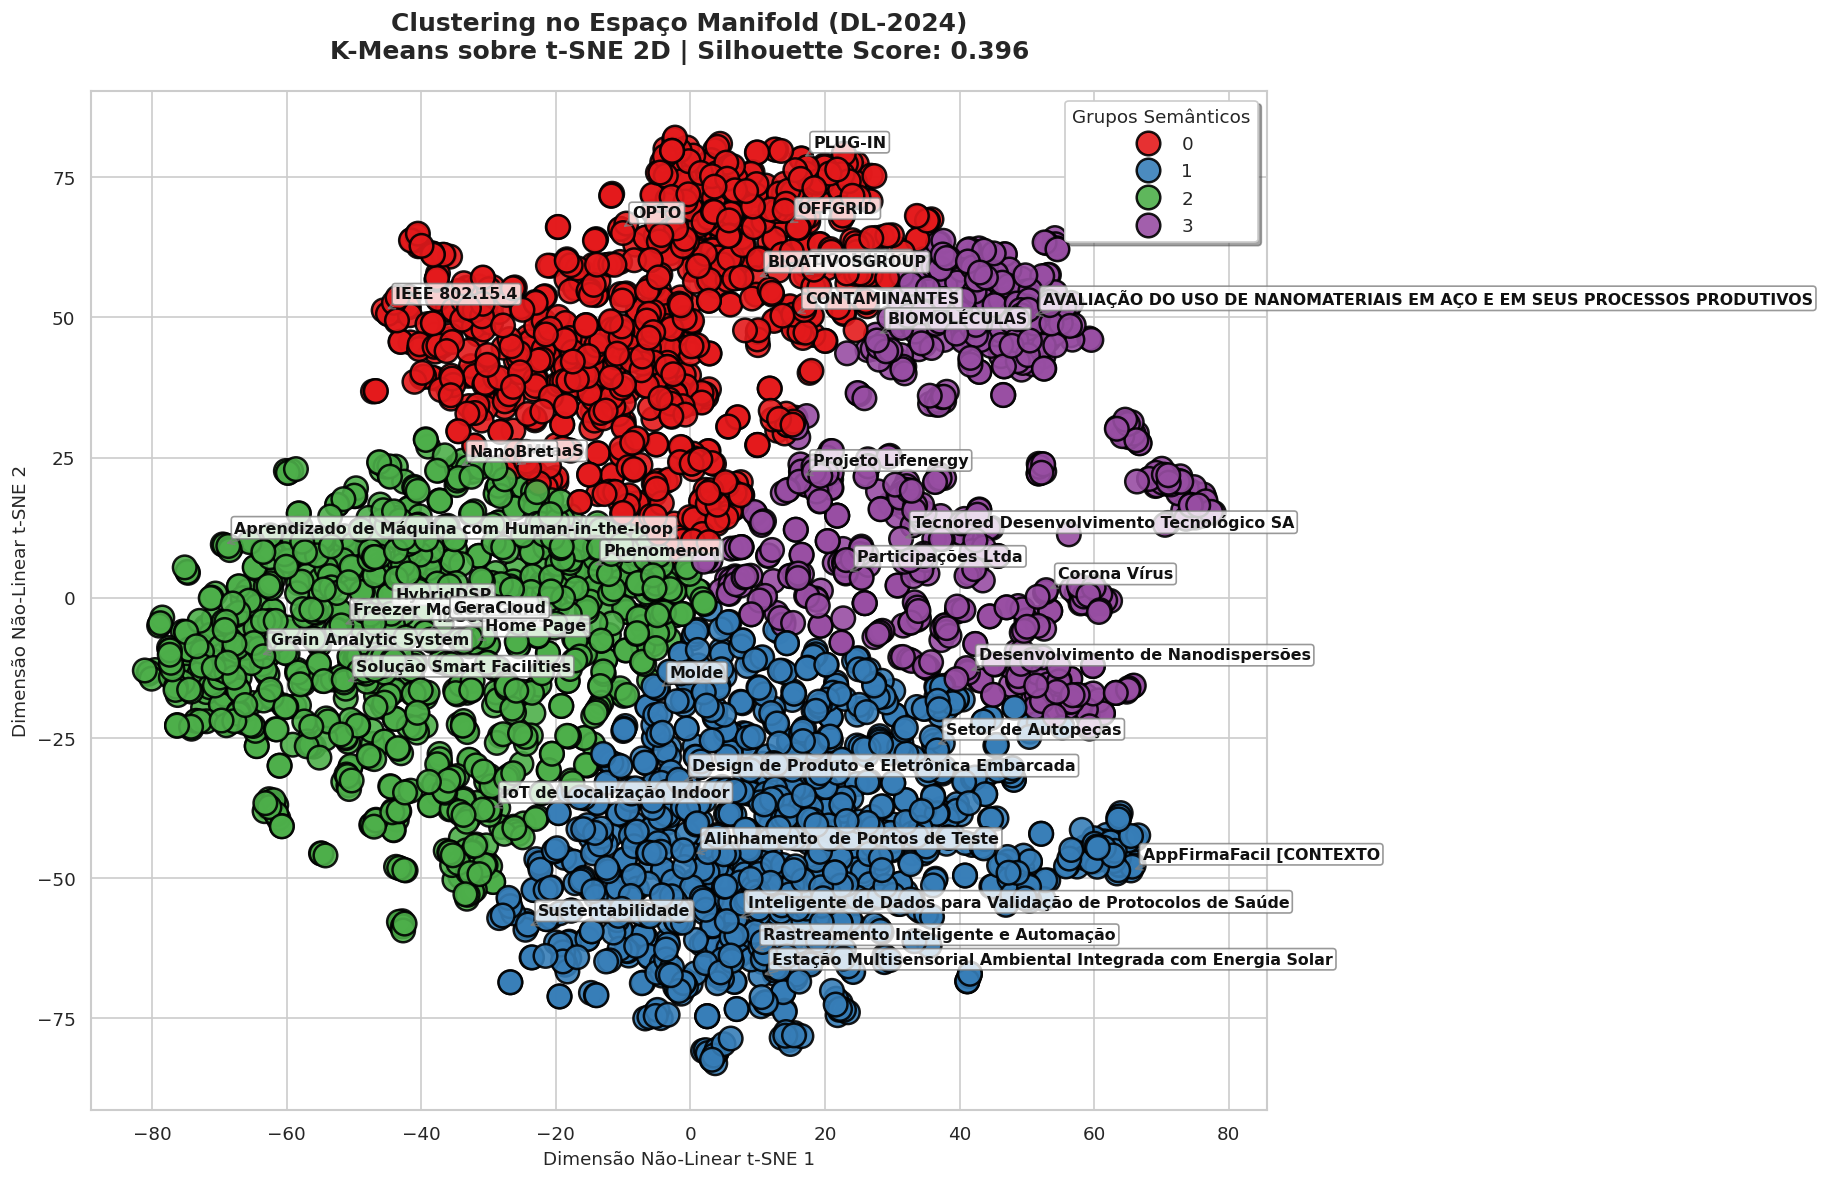

In [10]:
# Célula 6: Clustering Não-Linear no Espaço t-SNE (A Otimização Definitiva)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'X_embeddings' in locals() and len(vocabulario_entidades) > 5:
    
    # 1. Normalização Direcional L2
    X_norm = normalize(X_embeddings, norm='l2')

    perplexidade = min(15, max(2, len(vocabulario_entidades) // 3))
    tsne = TSNE(
        n_components=2, 
        perplexity=perplexidade, 
        early_exaggeration=12.0, 
        learning_rate='auto', 
        init='pca', 
        random_state=42
    )
    # Extraímos as 2 dimensões mais relevantes do espaço não-linear
    coordenadas_2d = tsne.fit_transform(X_norm)

    # 3. K-Means atuando DIRETAMENTE no espaço projetado (t-SNE Space)
    k_ideal = min(4, len(vocabulario_entidades) // 3)
    if k_ideal < 2: k_ideal = 2
        
    kmeans = KMeans(n_clusters=k_ideal, init='k-means++', random_state=42, n_init=50)
    # Alimentamos o K-Means com as coordenadas do t-SNE, não com as do PCA/BERT
    labels_clusters = kmeans.fit_predict(coordenadas_2d)

    # 4. Cálculo do Silhouette Score 
    score_silhueta = silhouette_score(coordenadas_2d, labels_clusters)
    print(f"Qualidade do Agrupamento (Silhouette Score - t-SNE Manifold): {score_silhueta:.4f}")

    # 5. Geração do Gráfico Científico Final
    plt.figure(figsize=(15, 10), dpi=120)
    sns.set_theme(style="whitegrid") 
    
    sns.scatterplot(
        x=coordenadas_2d[:, 0], y=coordenadas_2d[:, 1], 
        hue=labels_clusters, palette="Set1", 
        s=200, alpha=0.9, edgecolor="black", linewidth=1.5
    )

    np.random.seed(42)
    max_anotacoes = min(35, len(vocabulario_entidades))
    indices_para_anotar = np.random.choice(len(vocabulario_entidades), max_anotacoes, replace=False)

    for idx in indices_para_anotar:
        plt.annotate(
            vocabulario_entidades[idx], 
            (coordenadas_2d[idx, 0], coordenadas_2d[idx, 1]),
            fontsize=9.5, fontweight='600', color='#111111',
            xytext=(7, 7), textcoords='offset points',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8),
            arrowprops=dict(arrowstyle="->", color='gray', alpha=0.7, connectionstyle="arc3,rad=0.1")
        )

    plt.title(f"Clustering no Espaço Manifold (DL-2024)\nK-Means sobre t-SNE 2D | Silhouette Score: {score_silhueta:.3f}", fontsize=15, fontweight='bold', pad=20)
    plt.xlabel("Dimensão Não-Linear t-SNE 1", fontsize=11)
    plt.ylabel("Dimensão Não-Linear t-SNE 2", fontsize=11)
    plt.legend(title="Grupos Semânticos", title_fontsize='11', loc='best', frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()
else:
    print("Massa de dados insuficiente para gerar visualizações.")